# Ubisoft Steam Reviews Sentiment Analysis

This project analyzes player sentiment on Ubisoft games using large-scale Steam reviews.

## Objectives
- Build a sentiment analysis model using PySpark
- Predict sentiment on Ubisoft reviews
- Filter noisy/spam reviews
- Perform statistical analysis (per game / per month)
- Extract keywords and visualize trends

In [1]:
import os
import sys

current_python = sys.executable

os.environ["PYSPARK_PYTHON"] = current_python
os.environ["PYSPARK_DRIVER_PYTHON"] = current_python
os.environ.setdefault("HADOOP_HOME", r"C:\hadoop")

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("SentimentAnalysis")
    .config("spark.ui.enabled", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

In [ ]:
#Load Cleaned Data
df = spark.read.parquet("outputs/ubisoft_all_with_pred.parquet")

df.show(5)
df.printSchema()

## Sentiment Prediction

We trained a sentiment classifier using PySpark (Logistic Regression with text features).
The model predicts:
- pred_label (0 = negative, 1 = positive)
- pos_prob (probability of positive sentiment)

## Spam Filtering

We remove low-quality reviews using token-based heuristics:
- minimum token count
- unique token ratio
- repetition detection

In [4]:
import os
import glob
import pandas as pd

def read_spark_csv(path: str) -> pd.DataFrame:
    if os.path.isdir(path):
        parts = glob.glob(os.path.join(path, "part-*.csv"))
        if not parts:
            raise FileNotFoundError(f"No part-*.csv in {path}")
        if len(parts) == 1:
            return pd.read_csv(parts[0])
        return pd.concat([pd.read_csv(p) for p in parts], ignore_index=True)
    return pd.read_csv(path)

print("Current working directory:", os.getcwd())

per_game = read_spark_csv("outputs_analysis/per_game_stats.csv")
per_month = read_spark_csv("outputs_analysis/per_month_stats.csv")

display(per_game.head())
display(per_month.head())

Current working directory: G:\Vmi\S2\BigData\SteamReview


,app_id,n_reviews,pred_positive_rate,avg_pos_prob,share_high_quality
0,359550,56090,0.598342,0.509432,0.642396
1,304390,48687,0.609957,0.522350,0.694498
2,552520,45995,0.727405,0.606867,0.738885
3,812140,38166,0.854216,0.705026,0.773987
4,220240,30168,0.798926,0.664871,0.678865


,review_month,n_reviews,pred_positive_rate,avg_pos_prob
0,2010-10,8,0.875000,0.669422
1,2010-11,124,0.951613,0.744525
2,2010-12,163,0.914110,0.759354
3,2011-01,101,0.920792,0.748153
4,2011-02,59,0.864407,0.705403


In [7]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
def spark_csv_exists(path):
    if os.path.isfile(path):
        return True
    if os.path.isdir(path):
        parts = glob.glob(os.path.join(path, "part-*.csv"))
        return len(parts) > 0
    return False

def read_spark_csv(path):
    if os.path.isdir(path):
        parts = glob.glob(os.path.join(path, "part-*.csv"))
        if len(parts) == 1:
            return pd.read_csv(parts[0])
        return pd.concat([pd.read_csv(p) for p in parts], ignore_index=True)
    return pd.read_csv(path)

def shorten(s, width=45):
    s = str(s)
    return s if len(s) <= width else s[:width - 1] + "…"

In [9]:
BASE = "outputs_analysis"
MAP_FILE = "preprocessing/ubisoft_list_simple.csv"

PER_GAME = os.path.join(BASE, "per_game_stats.csv")
PER_MONTH = os.path.join(BASE, "per_month_stats.csv")
PER_MONTH_TIER = os.path.join(BASE, "per_month_tier_stats.csv")

dfg = read_spark_csv(PER_GAME)
dfm = read_spark_csv(PER_MONTH)

In [10]:
id_col = "app_id"
n_col = "n_reviews"
rate_col = "pred_positive_rate"

gm = pd.read_csv(MAP_FILE)
gm["app_id"] = gm["app_id"].astype(str)
id_to_name = dict(zip(gm["app_id"], gm["name"]))

dfg["app_id"] = dfg["app_id"].astype(str)
dfg["game_name"] = dfg["app_id"].map(id_to_name).fillna(dfg["app_id"])

dfg["neg_rate"] = 1 - dfg[rate_col]

MIN_REVIEWS = 5000
N = 15

dfg2 = dfg[dfg[n_col] >= MIN_REVIEWS].copy()

### Top Positive Games

This figure presents the games with the highest predicted positive sentiment, filtered by a minimum number of reviews to ensure statistical reliability.

The results show that certain Ubisoft titles consistently achieve very high satisfaction levels, with positive rates close to 1.0. These games are likely well-received due to strong gameplay design, stable performance, and continuous support from developers.

By focusing only on games with a large number of reviews, the analysis avoids bias from small sample sizes and provides a more robust comparison across titles.

Overall, this highlights the most successful games in terms of player satisfaction within the dataset.

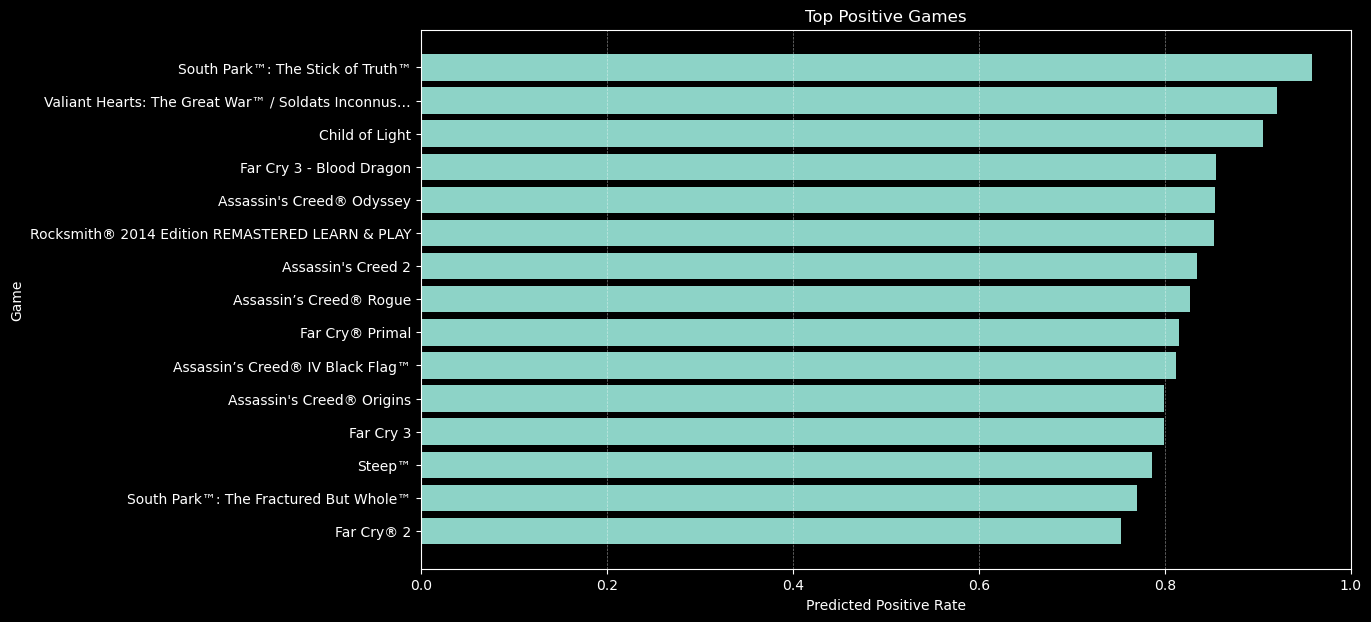

In [13]:
top_pos = dfg2.sort_values(rate_col, ascending=False).head(N).copy()
top_pos["game_short"] = top_pos["game_name"].apply(lambda x: shorten(x, 50))
top_pos = top_pos.sort_values(rate_col, ascending=True)

plt.figure(figsize=(12, 7))
plt.barh(top_pos["game_short"], top_pos[rate_col])
plt.xlabel("Predicted Positive Rate")
plt.ylabel("Game")
plt.title("Top Positive Games")
plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.5)

xmax = float(top_pos[rate_col].max())
plt.xlim(0, min(1.0, xmax * 1.1))

plt.show()

### Top Negative Games

This figure highlights the games with the lowest predicted positive sentiment, corresponding to the highest negative rates.

These titles tend to receive more critical feedback from players, which may be related to technical issues, lack of content, or unmet expectations. Compared to the top positive games, the sentiment scores here are significantly lower, indicating dissatisfaction among users.

Identifying these negatively perceived games is important for understanding potential weaknesses in game design or post-release support.

This analysis provides valuable insights into which titles may require improvement or further investigation.

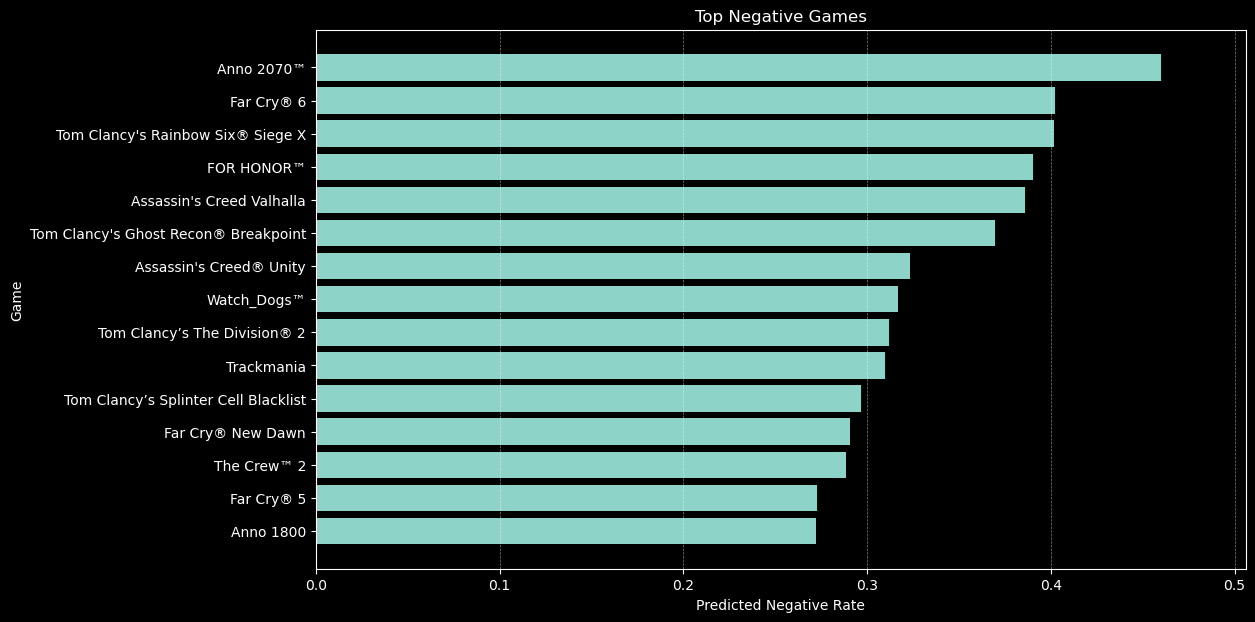

In [14]:
top_neg = dfg2.sort_values(rate_col, ascending=True).head(N).copy()
top_neg["neg_rate"] = 1 - top_neg[rate_col]
top_neg["game_short"] = top_neg["game_name"].apply(lambda x: shorten(x, 50))
top_neg = top_neg.sort_values("neg_rate", ascending=True)

plt.figure(figsize=(12, 7))
plt.barh(top_neg["game_short"], top_neg["neg_rate"])
plt.xlabel("Predicted Negative Rate")
plt.ylabel("Game")
plt.title("Top Negative Games")
plt.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.5)

xmax = float(top_neg["neg_rate"].max())
plt.xlim(0, min(1.0, xmax * 1.1))

plt.show()

### Monthly Sentiment Trend

This figure illustrates the evolution of predicted positive sentiment over time across all Ubisoft Steam reviews.

The overall trend shows that sentiment remains relatively high, generally above 0.7, indicating a broadly positive perception of Ubisoft games. However, several noticeable drops can be observed during specific periods, suggesting moments of lower player satisfaction.

For instance, a decline around 2016–2017 may be linked to fewer major releases or negative community reactions. After this period, sentiment stabilizes but does not fully return to earlier peak levels.

This temporal analysis provides insights into how player sentiment evolves in response to releases, updates, and broader industry trends.

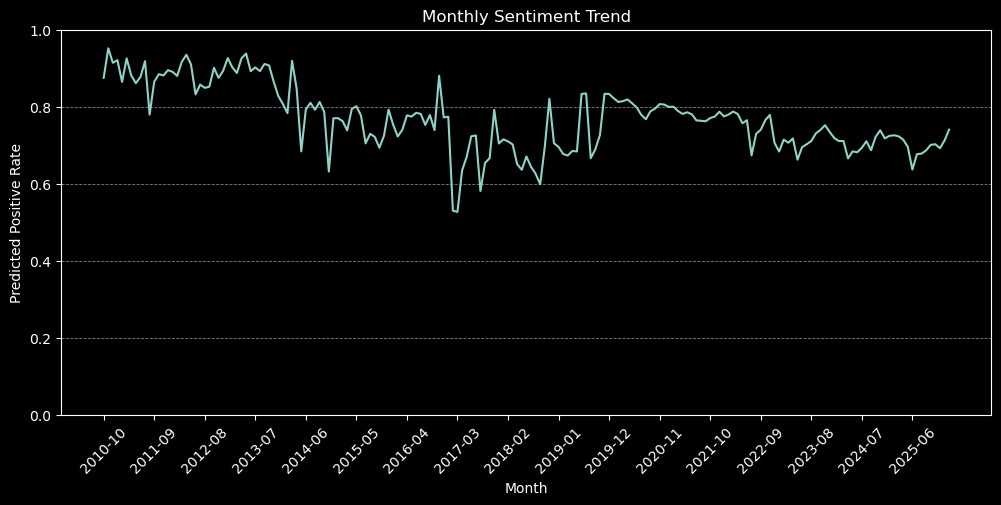

In [15]:
def set_month_ticks(x_values, max_ticks=16):
    n = len(x_values)
    step = max(1, n // max_ticks)
    idx = list(range(0, n, step))
    return idx, [str(x_values[i]) for i in idx]

dfm = dfm.sort_values("review_month").reset_index(drop=True)

idx, labels = set_month_ticks(dfm["review_month"].tolist())

plt.figure(figsize=(12, 5))
plt.plot(dfm["review_month"], dfm["pred_positive_rate"])
plt.xlabel("Month")
plt.ylabel("Predicted Positive Rate")
plt.title("Monthly Sentiment Trend")
plt.xticks([dfm["review_month"].iloc[i] for i in idx], labels, rotation=45)

plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

plt.show()

### Monthly Sentiment Trend by Review Quality Tier

This figure compares sentiment trends over time across different review quality tiers.

The results indicate that both tiers follow similar patterns, suggesting that global factors such as game releases or updates affect all reviews consistently. However, the high-quality tier generally exhibits slightly higher sentiment scores, indicating that more detailed or informative reviews tend to be more positive.

A significant drop in sentiment can be observed around certain periods, after which the trend stabilizes. This suggests that negative events or weaker releases impact all tiers but may be reflected differently depending on review quality.

Overall, this analysis confirms that while review quality influences sentiment levels, temporal dynamics remain the dominant factor.

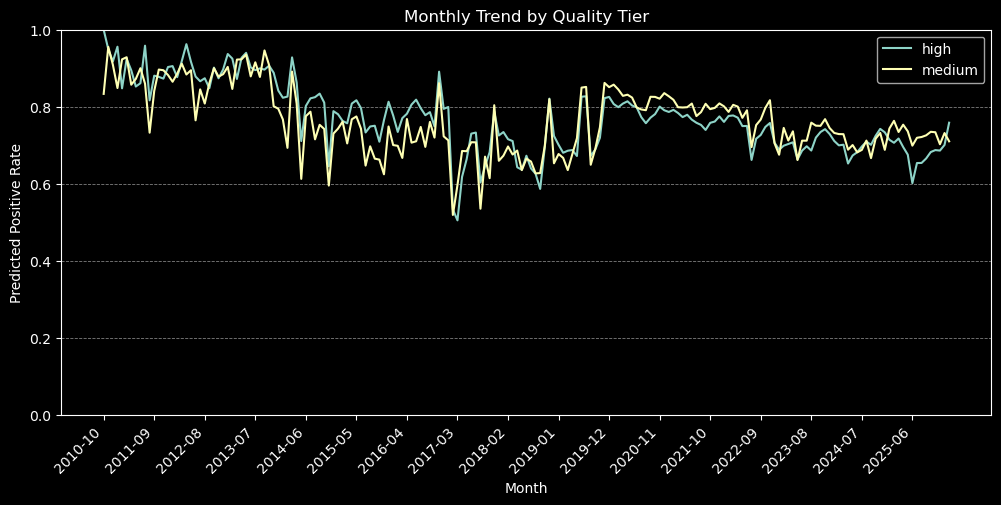

In [17]:
dft = read_spark_csv(PER_MONTH_TIER)
dft = dft.sort_values("review_month")

plt.figure(figsize=(12, 5))

for tier in sorted(dft["quality_tier"].dropna().unique()):
    sub = dft[dft["quality_tier"] == tier]
    plt.plot(sub["review_month"], sub["pred_positive_rate"], label=str(tier))

plt.xlabel("Month")
plt.ylabel("Predicted Positive Rate")
plt.title("Monthly Trend by Quality Tier")

plt.ylim(0, 1.0)
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
plt.legend()

def set_month_ticks(x_values, max_ticks=16):
    n = len(x_values)
    step = max(1, n // max_ticks)
    idx = list(range(0, n, step))
    return idx, [str(x_values[i]) for i in idx]

months = sorted(dft["review_month"].astype(str).unique())
idx, labels = set_month_ticks(months, max_ticks=16)

plt.xticks([months[i] for i in idx], labels, rotation=45, ha="right")

plt.show()

### WordCloud Analysis

To qualitatively analyze review content, word clouds are generated from the spam-filtered prediction results.

Only reviews with strong sentiment confidence are retained:
- positive reviews with `pos_prob >= 0.8`
- negative reviews with `pos_prob <= 0.2`

The text is normalized by removing non-alphabetic characters, filtering short words, and excluding stopwords as well as common domain-specific words.

This makes it possible to highlight the most representative terms associated with positive and negative player feedback.

In [24]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

df_wc = pd.read_parquet(
    "outputs/ubisoft_all_with_pred_spamfiltered.parquet",
    columns=["pred_label", "pos_prob", "clean_text"]
)
df_wc = df_wc[df_wc["clean_text"].notna()].copy()

In [25]:
EXTRA_STOP = {
    "game","games","ubisoft","uplay","steam","play","played","playing",
    "player","players","one","really","also","still","get","got",
    "im","ive","dont","didnt","cant","couldnt","would","thats","story","time",
    "even",
}
STOP = set(STOPWORDS) | EXTRA_STOP

def normalize_text(s):
    s = (s or "").lower()
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return " ".join([w for w in s.split() if len(w) >= 3 and w not in STOP])

In [26]:
def build_wc(texts, title):
    txt = " ".join(normalize_text(t) for t in texts if isinstance(t, str))
    if not txt.strip():
        return

    wc = WordCloud(
        width=1600,
        height=900,
        background_color="white",
        max_words=250,
        collocations=False,
        stopwords=STOP,
    ).generate(txt)

    plt.figure(figsize=(12, 7))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(title)
    plt.show()

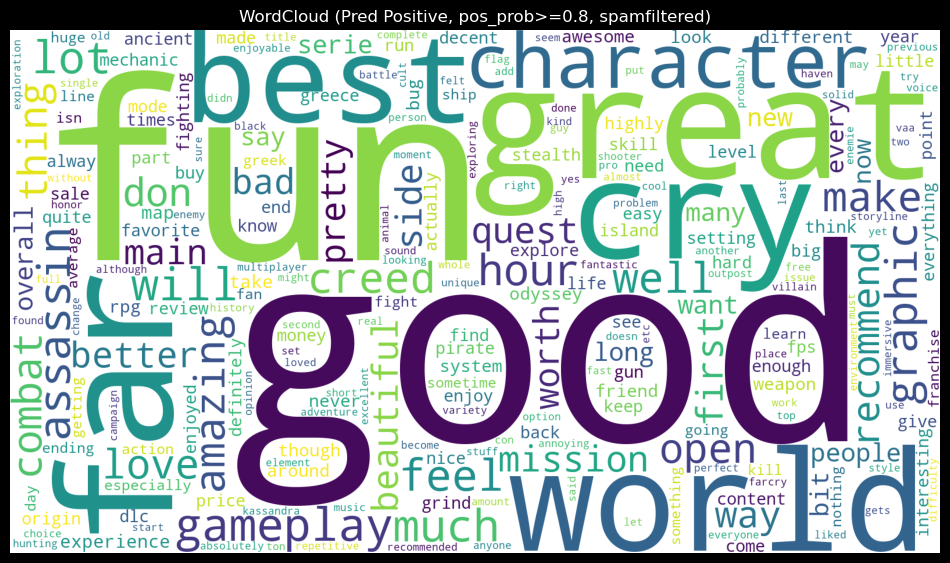

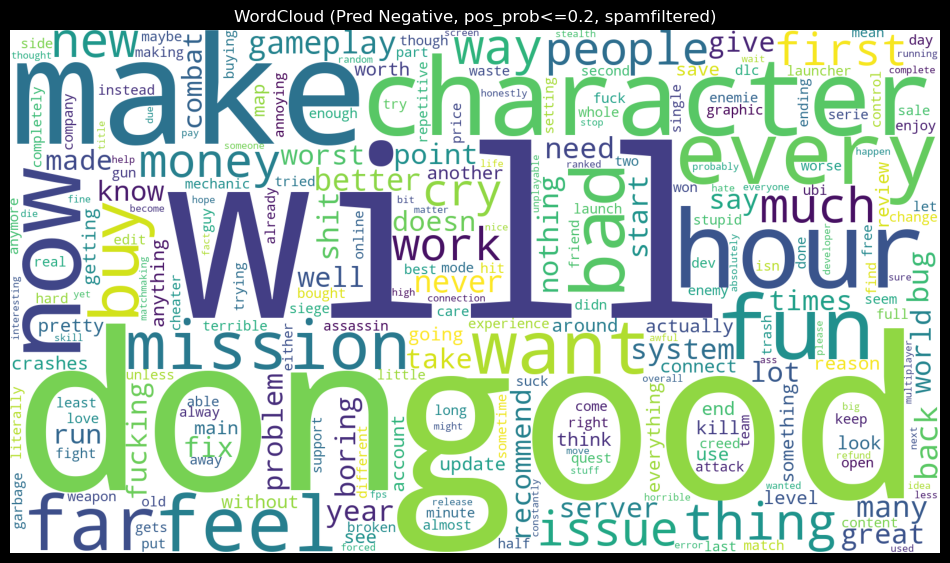

In [27]:
MAX_DOCS = 40000

pos_texts = (
    df_wc[df_wc["pos_prob"] >= 0.8]["clean_text"]
    .head(MAX_DOCS)
    .tolist()
)

neg_texts = (
    df_wc[df_wc["pos_prob"] <= 0.2]["clean_text"]
    .head(MAX_DOCS)
    .tolist()
)

build_wc(pos_texts, "WordCloud (Pred Positive, pos_prob>=0.8, spamfiltered)")
build_wc(neg_texts, "WordCloud (Pred Negative, pos_prob<=0.2, spamfiltered)")

# Sentiment Analysis with PySpark

**Author:** Xiangrui Feng
**Model:** TF-IDF / HashingTF + Logistic Regression
**Datasets:** Steam, Social, Twitter (shared), ALL

## Introduction

The objective of this notebook is to perform sentiment analysis using PySpark.

We evaluate a Logistic Regression classifier on several datasets:

- Steam (our own dataset)
- Social dataset
- Shared normalized Twitter dataset
- Combined dataset (ALL)

The evaluation metrics are:

- Accuracy
- Precision
- Recall
- F1-score